In [1]:
from fem.solver import CahnHilliardSolver
import numpy as np
import matplotlib.pyplot as plt

# Physics
epsilon = 0.01

# Discretization
L = 1
N = 50
poly_degree = 1


dt = 1e-8
tEnd = 1e-3
print(int(tEnd/dt))

# Initial conditions
def c0(x): return np.cos(np.pi*x)
# def c0(x): return np.sin(np.pi/(L)*x)


100000


# EXPLICIT SOLVER

In [2]:
explicit = CahnHilliardSolver(epsilon, 
                         number_of_elements=N, L = L, 
                         polynomial_order=1)
explicit.solve(c0, tEnd, dt, time_integrator=0)


100%|██████████| 100000/100000 [16:53<00:00, 98.68it/s]


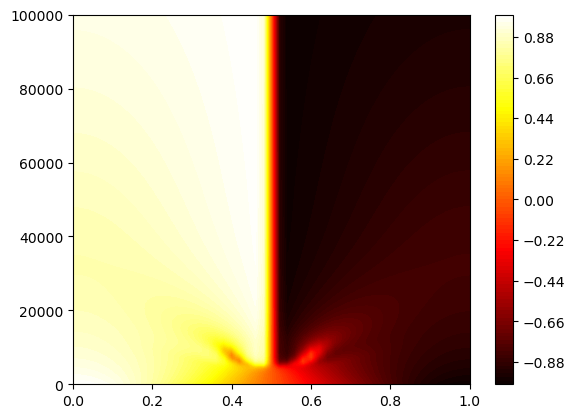

In [3]:
fig, ax = plt.subplots()
X, Y = np.meshgrid(explicit.x, explicit.t/dt)
C = ax.contourf(X, Y, explicit.sol_c, levels = 100, cmap = 'hot')
fig.colorbar(C);


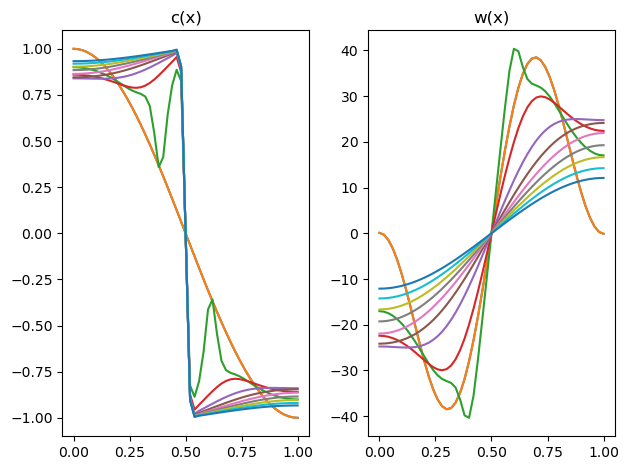

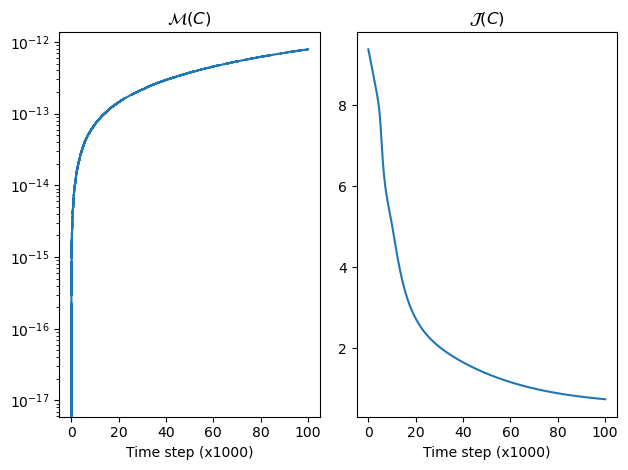

In [4]:
fig1, ax1 = plt.subplots(1,2)
ax1[0].plot(explicit.x, explicit.sol_c[0])
ax1[1].plot(explicit.x, explicit.sol_w[0])
if len(explicit.t) > 1:
    for i in range(1,len(explicit.t), max(len(explicit.t)//10,1)):
        ax1[0].plot(explicit.x, explicit.sol_c[i])
        ax1[1].plot(explicit.x, explicit.sol_w[i])
ax1[0].set_title('c(x)')
ax1[1].set_title('w(x)')
fig1.tight_layout()

fig2, ax2 = plt.subplots(1,2)
ax2[0].plot(explicit.t/dt/1e3, explicit.mass)
ax2[0].set_title('$\\mathcal{M}(C)$')
ax2[0].set_yscale('log')

ax2[1].plot(explicit.t/dt/1e3, explicit.J)
ax2[1].set_title('$\\mathcal{J}(C)$')
[_.set_xlabel('Time step (x1000)') for _ in ax2]
fig2.tight_layout()

## QUADRATIC ELEMENTS

In [ ]:
quad = CahnHilliardSolver(epsilon, 
                         number_of_elements=N, L = L, 
                         polynomial_order=2)
quad.solve(c0, tEnd, dt, time_integrator=0)